In [1]:
from defenders.multi_turn.TCA.statistical_significance_proof.utility import plot_hypothesis_test ,plot_bootstrap_distribution ,plot_box_separation
from defenders.multi_turn.TCA.statistical_significance_proof.statistical_test import simple_two_sample_test, simple_bootstrap_test

In [2]:
import pandas as pd

df = pd.read_csv("../../integrated/data/processed/train(7).csv")

In [3]:
result = simple_two_sample_test(
    df,
    score_col="threat_accel",
    label_col="label"
)

Mean Safe : 5.120225010182301
Mean Attack: 7.28170611727378
Difference : 2.161481107091479
Standard Error: 0.7064046951411087
t-statistic:3.0598340044437413
p-value:0.0022213660681795755
t-critical: 1.9602377667881852
95% CI : [0.7767599450393834, 3.5462022691435746]
Decision: REJECT H0


In [4]:
t_stat = result["t_stat"]
p_value = result["p_value"]
ci = result["ci"]
df_t = result["df"]

In [5]:
scores = df["threat_accel"].values
labels = df["label"].values

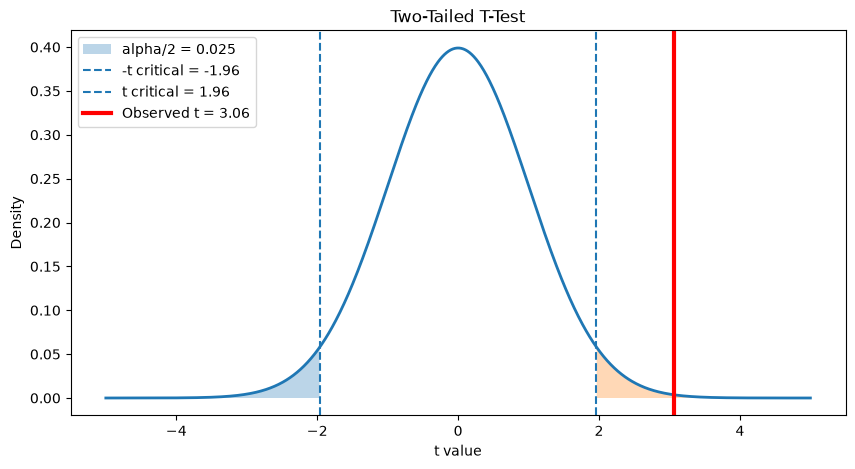

In [6]:
plot_hypothesis_test(
    t_stat=t_stat,
    df=df_t,
    alpha=0.05
)

In [7]:
diff ,ci ,bootstrap_diffs= simple_bootstrap_test(
    df, 
    feature_col="threat_accel",
    label_col="label",
    n_resamples=5000
)

Mean Safe:5.120225010182301
Mean Attack:7.28170611727378
Difference:2.161481107091479
95% CI: [0.8434320696296808,3.5238731963950096]
Decision: REJECT H0
Conclusion: Significant difference between groups


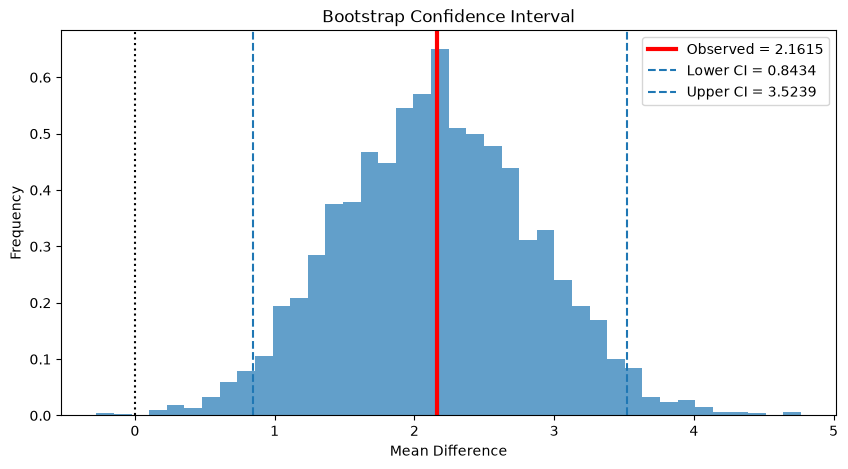

In [8]:
plot_bootstrap_distribution(
    bootstrap_diffs=bootstrap_diffs,
    observed_diff=diff,
    lower=ci[0],
    upper=ci[1]
)

In [9]:
features = df.columns.tolist()
#remove conv_id and turn_id and label
features.remove("conv_id")
features.remove("turn_id")
features.remove("label")
results = []

for feature in features:
    #each feature will see its significance test and bootstrap test
    diff, ci, bootstrap_diffs = simple_bootstrap_test(
        df,
        feature_col=feature,
        label_col="label",
        n_resamples=5000
    )

    significant = not (ci[0] <= 0 <= ci[1])

    results.append({
        "feature": feature,
        "difference": diff,
        "ci_lower": ci[0],
        "ci_upper": ci[1],
        "significant": significant,
        "bootstrap_diffs": bootstrap_diffs
    })

Mean Safe:-0.002893638417702661
Mean Attack:0.11202114035641296
Difference:0.11491477877411563
95% CI: [0.07851242785519091,0.15170100460423835]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.12314973566323056
Mean Attack:0.39706106120063234
Difference:0.520210796863863
95% CI: [0.48399476786661955,0.5551253784785501]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.18774148289765855
Mean Attack:0.16931374085898532
Difference:0.3570552237566439
95% CI: [0.33953382292831175,0.3749627686133234]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.014683280665883014
Mean Attack:0.3127412172937139
Difference:0.32742449795959694
95% CI: [0.2915653224259345,0.3639231662501689]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.43490965210399096
Mean Attack:-0.10732101448113388
Difference:0.32758863762285706
95% CI: [0.2905743553496788,0.36536194891606477]
Decisi

In [10]:
import pandas as pd

results_df_bootstrap_test = pd.DataFrame(results)

In [11]:
results_df_bootstrap_test["abs_difference"] = results_df_bootstrap_test ["difference"].abs()

results_df_bootstrap_test = results_df_bootstrap_test.sort_values(
    "abs_difference",
    ascending=False
)

In [12]:
print(results_df_bootstrap_test.head(10))

                  feature  difference   ci_lower   ci_upper  significant  \
21    max_toxicity_so_far   34.424990  25.990902  43.090236         True   
22      max_threat_so_far    2.973776   2.376584   3.600547         True   
10       interaction_risk    2.905980   1.966035   3.850081         True   
19           threat_accel    2.161481   0.843432   3.523873         True   
13      threat_score_ema3    1.998509   0.942645   3.091942         True   
12    toxicity_score_ema3    1.627835   1.116747   2.129749         True   
14  interaction_risk_ema3    1.453608   0.960214   1.945095         True   
11       progressive_risk    1.316882   1.223148   1.409290         True   
16          toxicity_diff   -1.248319  -3.118453   0.648807        False   
20           risk_slope_3   -0.810651  -0.939675  -0.682278         True   

                                      bootstrap_diffs  abs_difference  
21  [29.33210895196167, 34.40297248781895, 35.6791...       34.424990  
22  [3.328481733088

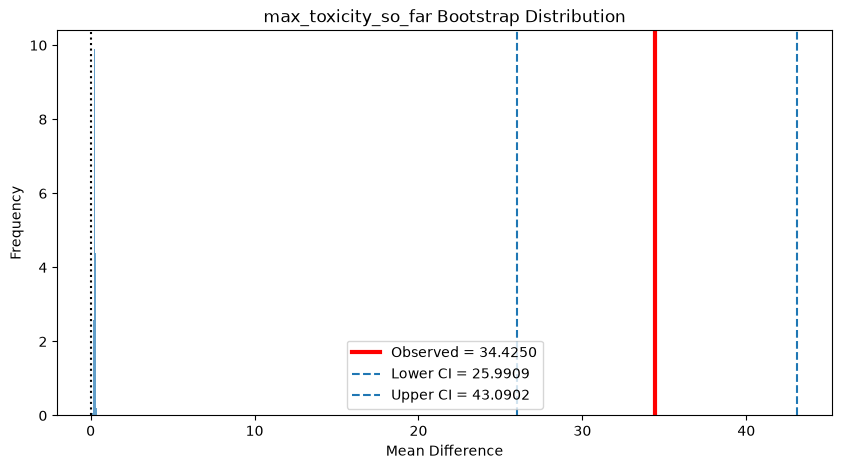

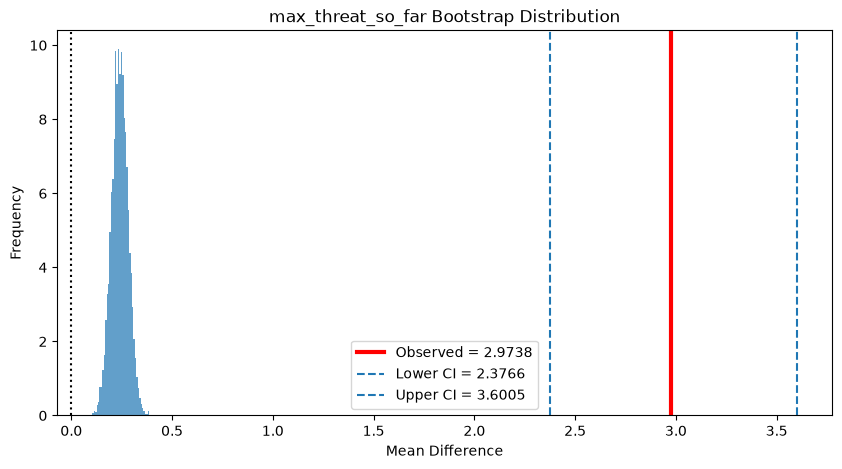

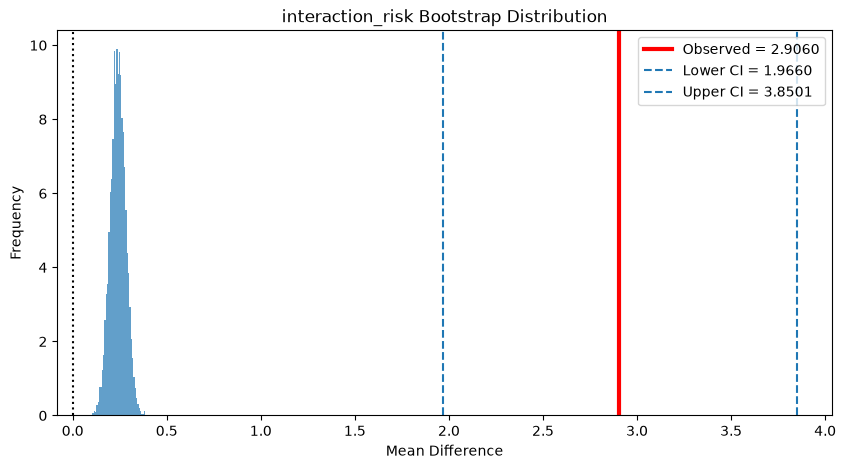

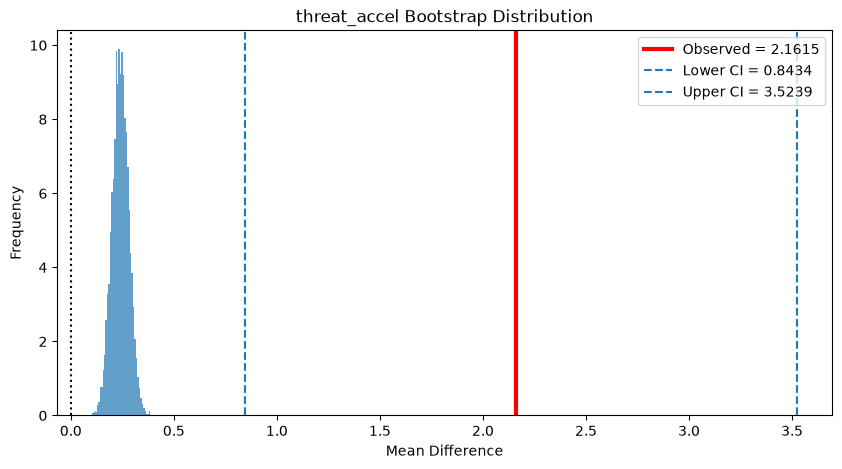

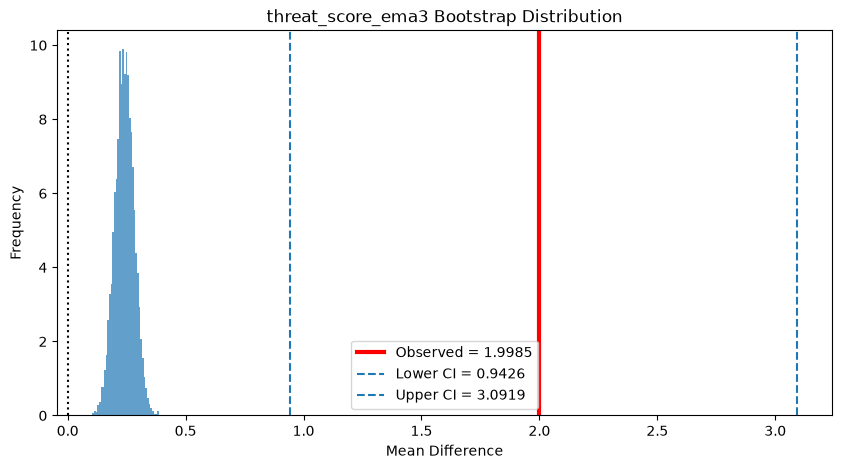

In [13]:
top_features = results_df_bootstrap_test.head(5)["feature"]

for feature in top_features:
    
    row = results_df_bootstrap_test[results_df_bootstrap_test["feature"] == feature].iloc[0]

  
    diff = row["difference"]
    ci_lower = row["ci_lower"]
    ci_upper = row["ci_upper"]

    
    scores = df[feature].values
    labels = df["label"].values

    
    plot_bootstrap_distribution(
        bootstrap_diffs=bootstrap_diffs,  
        observed_diff=diff,
        lower=ci_lower,
        upper=ci_upper,
        title=f"{feature} Bootstrap Distribution"
    )


In [14]:
features = df.columns.tolist()
#remove conv_id and turn_id and label
features.remove("conv_id")
features.remove("turn_id")
features.remove("label")
results = []

for feature in features:
    #each feature will see its significance test on two sample test
    result =simple_two_sample_test(
        df,
        score_col=feature,
        label_col="label",
      
        
    )

   
    significant = not (result['ci'][0] <= 0 <= result['ci'][1])

    results.append({
        't_stat': result['t_stat'],
        'p_value': result['p_value'],   
        'ci': result['ci'],
        'df': result['df'],
        'feature': feature,
       
    })

Mean Safe : -0.002893638417702661
Mean Attack: 0.11202114035641296
Difference : 0.11491477877411563
Standard Error: 0.01874794795321335
t-statistic:6.129459024576582
p-value:9.202902884197783e-10
t-critical: 1.9602377667881852
95% CI : [0.07816434314644757, 0.15166521440178368]
Decision: REJECT H0
Mean Safe : -0.12314973566323056
Mean Attack: 0.39706106120063234
Difference : 0.520210796863863
Standard Error: 0.017767803258298326
t-statistic:29.278284394605855
p-value:0.0
t-critical: 1.9602377667881852
95% CI : [0.48538167788408443, 0.5550399158436415]
Decision: REJECT H0
Mean Safe : -0.18774148289765855
Mean Attack: 0.16931374085898532
Difference : 0.3570552237566439
Standard Error: 0.009230151073721882
t-statistic:38.683573096996795
p-value:0.0
t-critical: 1.9602377667881852
95% CI : [0.33896193302877375, 0.37514851448451403]
Decision: REJECT H0
Mean Safe : -0.014683280665883014
Mean Attack: 0.3127412172937139
Difference : 0.32742449795959694
Standard Error: 0.018391601452751236
t-sta

In [15]:
import pandas as pd

results_df_two_sample = pd.DataFrame(results)

In [16]:

results_df_two_sample = results_df_two_sample.sort_values(
    "p_value",
    ascending=True
)

In [17]:
print(results_df_two_sample.head(10))

       t_stat  p_value                                          ci    df  \
1   29.278284      0.0   (0.48538167788408443, 0.5550399158436415)  8666   
2   38.683573      0.0  (0.33896193302877375, 0.37514851448451403)  8666   
3   17.802936      0.0   (0.2913725862001975, 0.36347640971899636)  8666   
4   16.900800      0.0   (0.2895932990634725, 0.36558397618224164)  8666   
6   23.836751      0.0      (0.33962754505267, 0.4004919735529996)  8666   
5   16.238110      0.0  (0.23309266253352506, 0.29709618374297814)  8666   
7   40.977386      0.0     (0.536068576492103, 0.5899331933095774)  8666   
9   61.485487      0.0    (0.6874626623293576, 0.7327406005806931)  8666   
15  31.225584      0.0    (0.6158782369078373, 0.6983831747331386)  8666   
11  27.865302      0.0     (1.2242436707072373, 1.409520858345242)  8666   

                   feature  
1             origin_drift  
2           drift_momentum  
3   persistent_drift_count  
4           distance_ratio  
6          mean_si

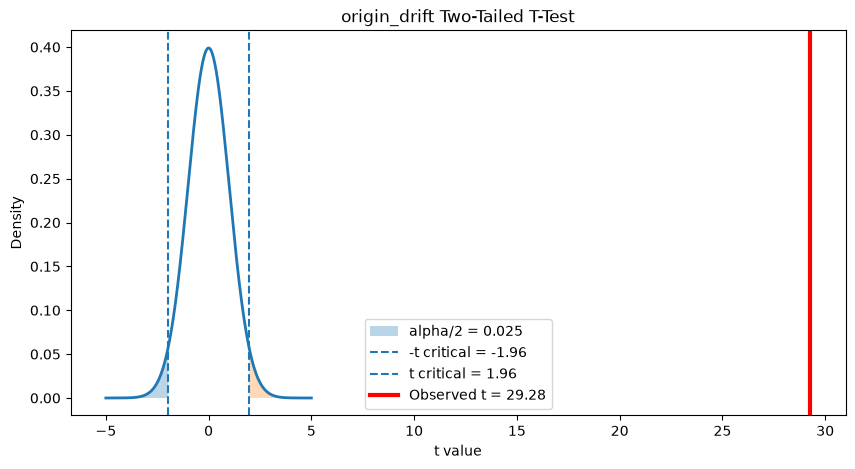

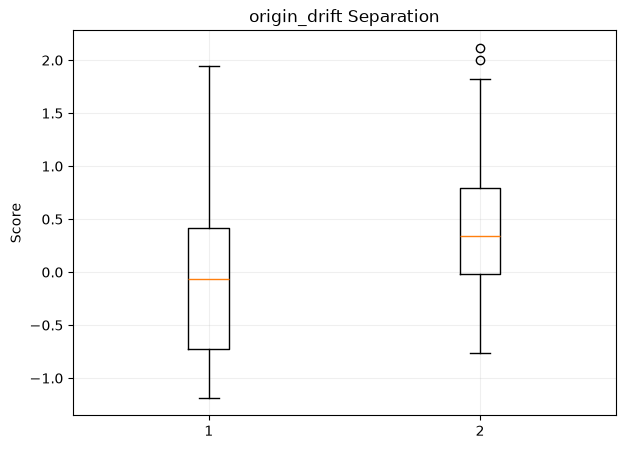

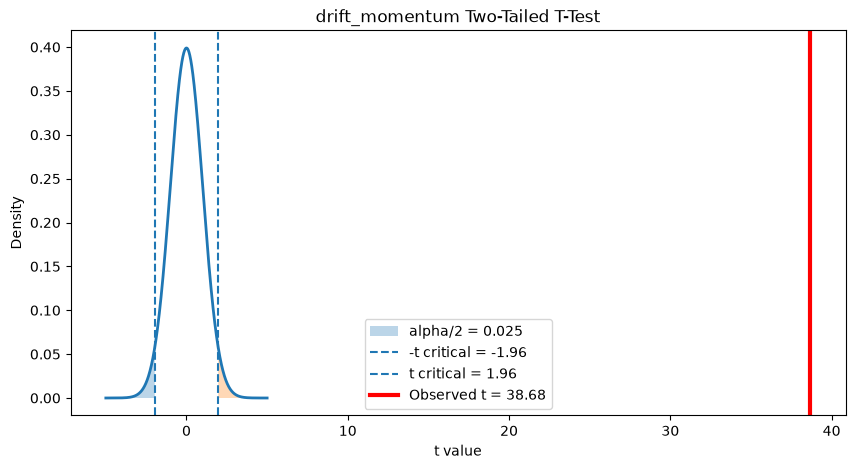

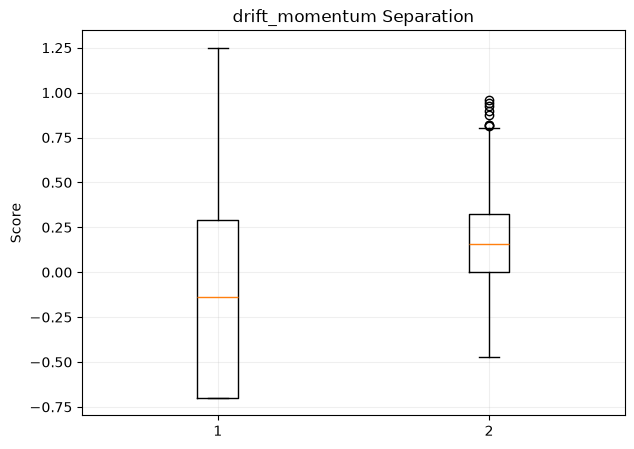

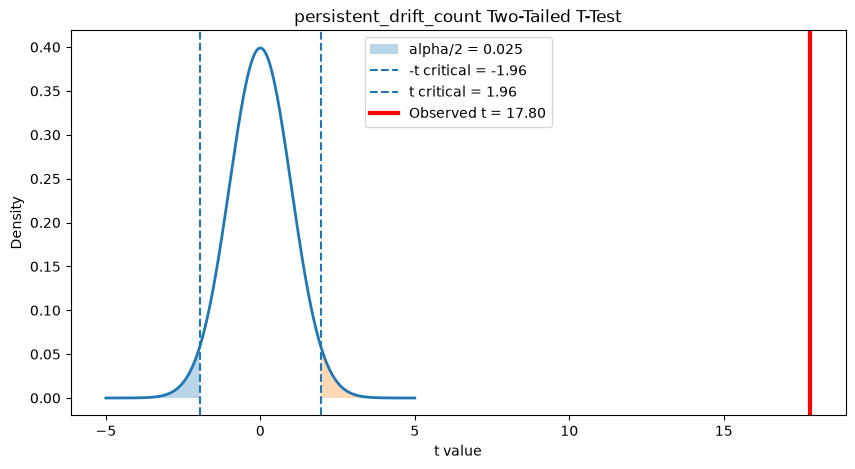

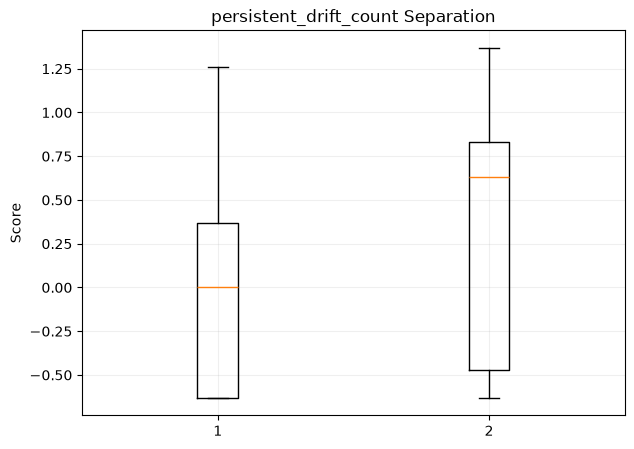

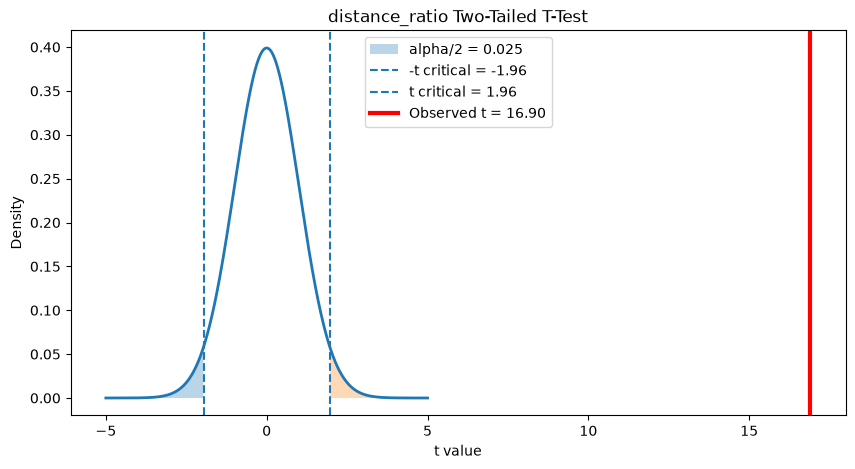

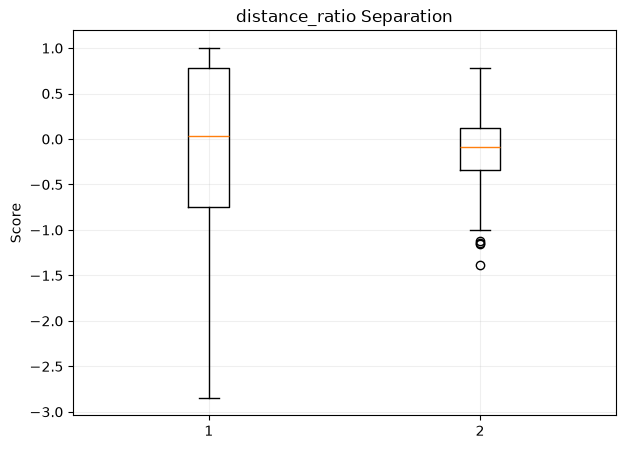

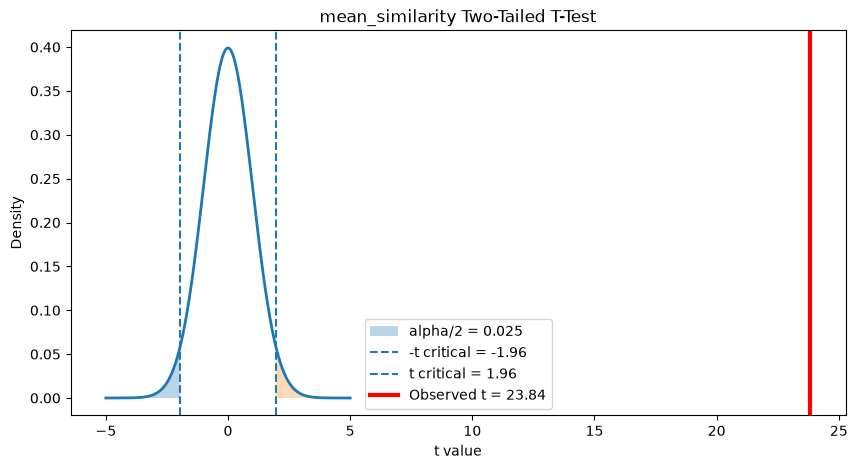

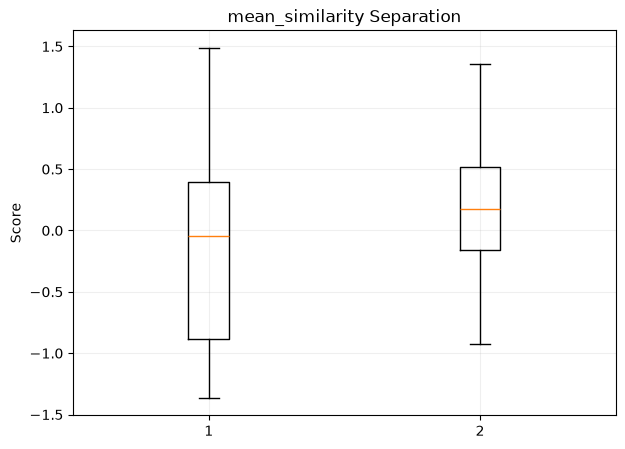

In [18]:

for feature in results_df_two_sample["feature"][:5]:
        
    scores = df[feature].values  
    labels = df["label"].values
    
    result = results_df_two_sample[results_df_two_sample["feature"] == feature].iloc[0]

    t_stat = result["t_stat"]
    p_value = result["p_value"]
    df_t = result["df"]
    

    plot_hypothesis_test(
    t_stat=t_stat,
    df=df_t,
    alpha=0.05,
    title=f"{feature} Two-Tailed T-Test"
    )

    plot_box_separation(
        scores,
        labels,
        class_names=("Safe", "Adversarial"),
        title=f"{feature} Separation"
    )

In [19]:
results_df_two_sample['ci_lower'] = results_df_two_sample['ci'].apply(lambda x: x[0])
results_df_two_sample['ci_upper'] = results_df_two_sample['ci'].apply(lambda x: x[1])

results_df_two_sample = results_df_two_sample.drop('ci', axis=1)

results_df_two_sample.to_csv("./data/two_sample_test_results.csv", index=False)


In [20]:
import json

results_json = []
for result in results_df_bootstrap_test.to_dict(orient="records"):
    results_json.append({
        "feature": result["feature"],
        "difference": float(result["difference"]),
        "ci_lower": float(result["ci_lower"]),
        "ci_upper": float(result["ci_upper"]),
        "significant": bool(result["significant"]),
        "bootstrap_diffs": result["bootstrap_diffs"]
    })

with open("./data/bootstrap_test_results.json", "w") as f:
    json.dump(results_json, f)

